<a href="https://colab.research.google.com/github/kavee2002bc/Diabetic-Retinopathy-Detection-System-DL/blob/efficientnet-Lakmi/IT23177246_EfficientNetB0_DDR_Diabetic_Retinopathy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


Check project files

In [2]:
!ls "/content/drive/MyDrive/DL Project"

01_DDR_Dataset_EDA.ipynb  ddr_common_split.csv	DDR.zip


Extract DDR dataset

In [3]:
import os

# Create temporary folder
os.makedirs("/content/DDR", exist_ok=True)

# Extract DDR.zip
!unzip -q \
"/content/drive/MyDrive/DL Project/DDR.zip" \
-d "/content/DDR"

print("DDR dataset extraction completed!")

DDR dataset extraction completed!


Check folders

In [4]:
!find "/content/DDR" -maxdepth 3 -type d

/content/DDR
/content/DDR/DR_grading
/content/DDR/DR_grading/DR_grading


Check image files

In [5]:
!find "/content/DDR" -type f | head -20


/content/DDR/DR_grading.csv
/content/DDR/DR_grading/DR_grading/007-0004-000.jpg
/content/DDR/DR_grading/DR_grading/007-0007-000.jpg
/content/DDR/DR_grading/DR_grading/007-0008-000.jpg
/content/DDR/DR_grading/DR_grading/007-0009-000.jpg
/content/DDR/DR_grading/DR_grading/007-0011-000.jpg
/content/DDR/DR_grading/DR_grading/007-0013-000.jpg
/content/DDR/DR_grading/DR_grading/007-0022-000.jpg
/content/DDR/DR_grading/DR_grading/007-0023-000.jpg
/content/DDR/DR_grading/DR_grading/007-0024-000.jpg
/content/DDR/DR_grading/DR_grading/007-0025-000.jpg
/content/DDR/DR_grading/DR_grading/007-0026-000.jpg
/content/DDR/DR_grading/DR_grading/007-0028-000.jpg
/content/DDR/DR_grading/DR_grading/007-0029-000.jpg
/content/DDR/DR_grading/DR_grading/007-0030-000.jpg
/content/DDR/DR_grading/DR_grading/007-0031-000.jpg
/content/DDR/DR_grading/DR_grading/007-0032-000.jpg
/content/DDR/DR_grading/DR_grading/007-0033-000.jpg
/content/DDR/DR_grading/DR_grading/007-0034-000.jpg
/content/DDR/DR_grading/DR_grading/0

Load dataset CSV

In [6]:
import pandas as pd
import os

# Paths
IMAGE_DIR = "/content/DDR/DR_grading/DR_grading"
SPLIT_PATH = "/content/drive/MyDrive/DL Project/ddr_common_split.csv"

# Load common split
df = pd.read_csv(SPLIT_PATH)

# Rebuild filepath for this Colab runtime
df["filepath"] = df["id_code"].apply(
    lambda x: os.path.join(IMAGE_DIR, x)
)

# Check files
df["exists"] = df["filepath"].apply(os.path.exists)

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (12522, 5)

Column names:
['id_code', 'diagnosis', 'filepath', 'exists', 'split']

First 5 rows:


,id_code,diagnosis,filepath,exists,split
0,20170209143259326.jpg,0,/content/DDR/DR_grading/DR_grading/20170209143...,True,train
1,007-3253-100.jpg,1,/content/DDR/DR_grading/DR_grading/007-3253-10...,True,train
2,007-6141-300.jpg,2,/content/DDR/DR_grading/DR_grading/007-6141-30...,True,train
3,007-3697-200.jpg,2,/content/DDR/DR_grading/DR_grading/007-3697-20...,True,train
4,007-7323-601.jpg,0,/content/DDR/DR_grading/DR_grading/007-7323-60...,True,train


Split + class distribution

In [7]:
print("=== SPLIT DISTRIBUTION ===")

print(df["split"].value_counts())

print("\n=== CLASS DISTRIBUTION ===")

print(
    df["diagnosis"]
    .value_counts()
    .sort_index()
)

=== SPLIT DISTRIBUTION ===
split
train         8765
test          1879
validation    1878
Name: count, dtype: int64

=== CLASS DISTRIBUTION ===
diagnosis
0    6266
1     630
2    4477
3     236
4     913
Name: count, dtype: int64


Class distribution for each split

In [8]:
print("=== TRAIN CLASS DISTRIBUTION ===")

print(
    df[df["split"] == "train"]["diagnosis"]
    .value_counts()
    .sort_index()
)

print("\n=== VALIDATION CLASS DISTRIBUTION ===")

print(
    df[df["split"] == "validation"]["diagnosis"]
    .value_counts()
    .sort_index()
)

print("\n=== TEST CLASS DISTRIBUTION ===")

print(
    df[df["split"] == "test"]["diagnosis"]
    .value_counts()
    .sort_index()
)

=== TRAIN CLASS DISTRIBUTION ===
diagnosis
0    4386
1     441
2    3134
3     165
4     639
Name: count, dtype: int64

=== VALIDATION CLASS DISTRIBUTION ===
diagnosis
0    940
1     94
2    671
3     36
4    137
Name: count, dtype: int64

=== TEST CLASS DISTRIBUTION ===
diagnosis
0    940
1     95
2    672
3     35
4    137
Name: count, dtype: int64


Check missing image

In [9]:
print("=== IMAGE FILE CHECK ===")

print(df["exists"].value_counts())

=== IMAGE FILE CHECK ===
exists
True    12522
Name: count, dtype: int64


In [10]:
train_df = df[df["split"] == "train"].copy()
val_df = df[df["split"] == "validation"].copy()
test_df = df[df["split"] == "test"].copy()

print("Train images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

Train images: 8765
Validation images: 1878
Test images: 1879


Display one image from each class

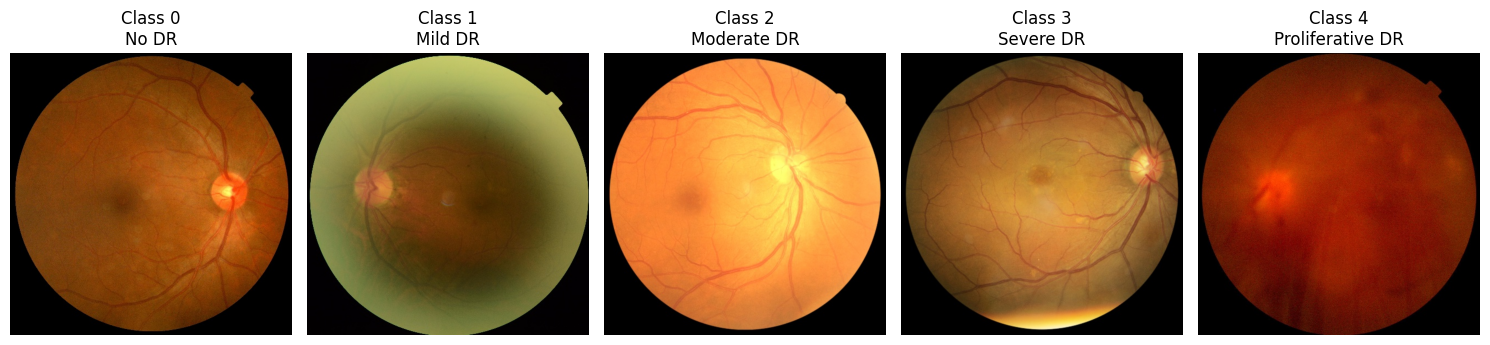

In [11]:
import matplotlib.pyplot as plt
from PIL import Image

class_names = {
    0: "No DR",
    1: "Mild DR",
    2: "Moderate DR",
    3: "Severe DR",
    4: "Proliferative DR"
}

plt.figure(figsize=(15, 10))

for i in range(5):

    class_data = train_df[train_df["diagnosis"] == i]

    sample = class_data.sample(
        n=1,
        random_state=42
    ).iloc[0]

    image = Image.open(sample["filepath"])

    plt.subplot(1, 5, i + 1)
    plt.imshow(image)
    plt.title(f"Class {i}\n{class_names[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

TensorFlow + configuration

In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 5
SEED = 42

print("TensorFlow version:", tf.__version__)
print(
    "GPU available:",
    tf.config.list_physical_devices("GPU")
)

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Create labels + generators

In [13]:
# Convert diagnosis labels to strings for Keras categorical generator

train_df["label"] = train_df["diagnosis"].astype(str)
val_df["label"] = val_df["diagnosis"].astype(str)
test_df["label"] = test_df["diagnosis"].astype(str)

print(
    train_df[["id_code", "diagnosis", "label"]].head()
)

print(
    "\nTrain label types:",
    train_df["label"].dtype
)

                 id_code  diagnosis label
0  20170209143259326.jpg          0     0
1       007-3253-100.jpg          1     1
2       007-6141-300.jpg          2     2
3       007-3697-200.jpg          2     2
4       007-7323-601.jpg          0     0

Train label types: object


Image generators

In [14]:
# Re-create generators for EfficientNetB0
# EfficientNetB0 already includes its input rescaling/preprocessing.

train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.10,
    horizontal_flip=True
)

val_test_datagen = tf.keras.preprocessing.image.ImageDataGenerator()

# Training generator
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

# Validation generator
val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

# Test generator
test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 8765 validated image filenames belonging to 5 classes.
Found 1878 validated image filenames belonging to 5 classes.
Found 1879 validated image filenames belonging to 5 classes.


EfficientNetB0 model

In [15]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

# Load EfficientNetB0 without the original ImageNet classifier
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

# Freeze pretrained base initially
base_model.trainable = False

# Build classification model
model = models.Sequential([
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.2),

    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,184 (16.08 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Calculate class weights

In [16]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Calculate class weights using training set only
classes = np.array(
    sorted(train_df["diagnosis"].unique())
)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["diagnosis"]
)

class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(
        classes,
        class_weights_array
    )
}

print("Class weights:")

for cls, weight in class_weights.items():
    print(f"Class {cls}: {weight:.4f}")

Class weights:
Class 0: 0.3997
Class 1: 3.9751
Class 2: 0.5593
Class 3: 10.6242
Class 4: 2.7433


Compile model

In [17]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


Callbacks

In [18]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

checkpoint_path = (
    "/content/drive/MyDrive/DL Project/"
    "IT23177246_EfficientNetB0_best.keras"
)

callbacks = [

    ModelCheckpoint(
        checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks created successfully.")

Callbacks created successfully.


Class weight variable

In [19]:
class_weight = class_weights

Training

In [20]:
EPOCHS = 15

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 706ms/step - accuracy: 0.4576 - loss: 1.9133
Epoch 1: val_loss improved from None to 1.42570, saving model to /content/drive/MyDrive/DL Project/IT23177246_EfficientNetB0_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DL Project/IT23177246_EfficientNetB0_best.keras
274/274 ━━━━━━━━━━━━━━━━━━━━ 262s 847ms/step - accuracy: 0.4350 - loss: 1.7919 - val_accuracy: 0.4462 - val_loss: 1.4257 - learning_rate: 1.0000e-05
Epoch 2/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 613ms/step - accuracy: 0.3703 - loss: 1.6930
Epoch 2: val_loss did not improve from 1.42570
274/274 ━━━━━━━━━━━━━━━━━━━━ 184s 671ms/step - accuracy: 0.3613 - loss: 1.6244 - val_accuracy: 0.3743 - val_loss: 1.5083 - learning_rate: 1.0000e-05
Epoch 3/15
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - accuracy: 0.3419 - loss: 1.5922
Epoch 3: val_loss did not improve from 1.42570

Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
274/274 ━━━━━━━━━━━━━━━━

Training History

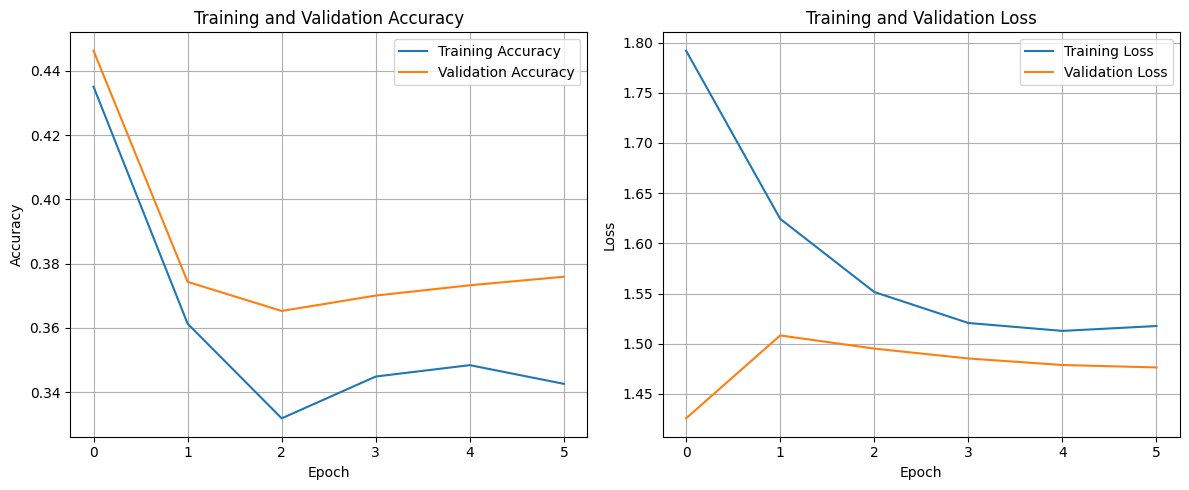

In [21]:
# Plot training history

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Test Set Evaluation

In [22]:
# Test Set Evaluation

test_loss, test_accuracy = model.evaluate(
    test_generator,
    verbose=1
)

print("\n=== TEST RESULTS ===")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

59/59 ━━━━━━━━━━━━━━━━━━━━ 30s 509ms/step - accuracy: 0.4369 - loss: 1.4295

=== TEST RESULTS ===
Test Loss: 1.4295
Test Accuracy: 0.4369
Test Accuracy: 43.69%


Classification Report

In [23]:
from sklearn.metrics import classification_report
import numpy as np

# Get predictions
test_generator.reset()

predictions = model.predict(test_generator, verbose=1)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

class_names = [
    "No DR",
    "Mild DR",
    "Moderate DR",
    "Severe DR",
    "Proliferative DR"
]

print("=== CLASSIFICATION REPORT ===")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

59/59 ━━━━━━━━━━━━━━━━━━━━ 30s 407ms/step
=== CLASSIFICATION REPORT ===
                  precision    recall  f1-score   support

           No DR     0.6072    0.5394    0.5713       940
         Mild DR     0.0000    0.0000    0.0000        95
     Moderate DR     0.3865    0.4509    0.4162       672
       Severe DR     0.0305    0.1714    0.0517        35
Proliferative DR     0.1351    0.0365    0.0575       137

        accuracy                         0.4369      1879
       macro avg     0.2319    0.2396    0.2193      1879
    weighted avg     0.4524    0.4369    0.4398      1879



 Confusion Matrix

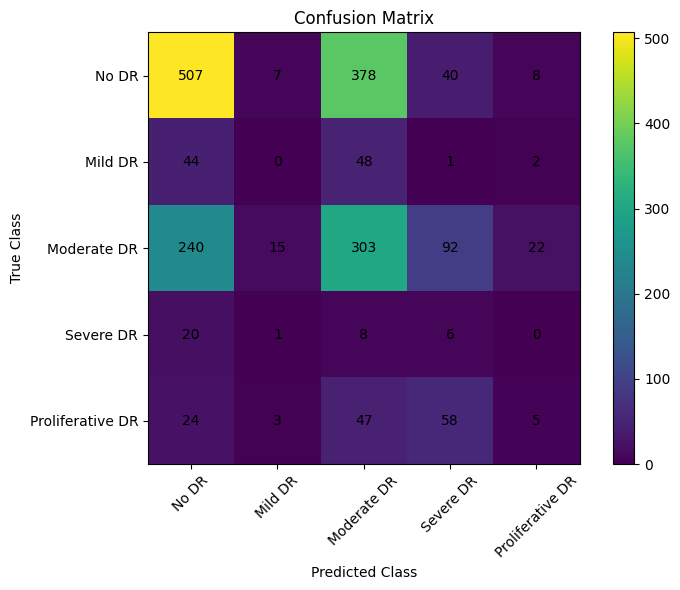

In [24]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(range(5), class_names, rotation=45)
plt.yticks(range(5), class_names)

for i in range(5):
    for j in range(5):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

 Final Model Results

EfficientNetB0 achieved a test accuracy of 43.69% on the DDR test set.
The classification report and confusion matrix were used to evaluate
the model performance across the five diabetic retinopathy classes.

ROC-AUC

59/59 ━━━━━━━━━━━━━━━━━━━━ 17s 278ms/step


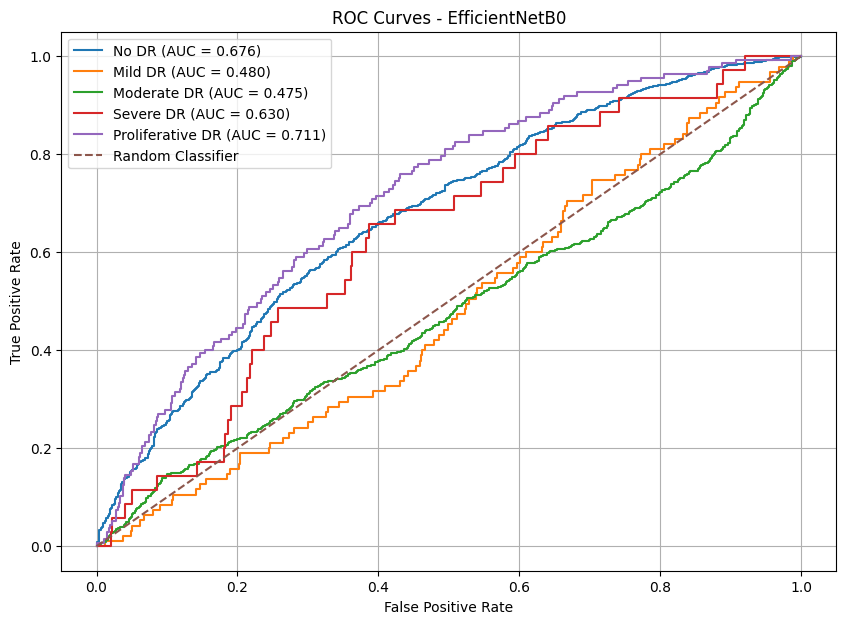


=== ROC-AUC Scores ===
No DR: 0.6762
Mild DR: 0.4797
Moderate DR: 0.4753
Severe DR: 0.6304
Proliferative DR: 0.7114


In [25]:
# ROC-AUC Evaluation

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Reset test generator
test_generator.reset()

# Prediction probabilities
y_prob = model.predict(
    test_generator,
    verbose=1
)

# True labels
y_true = test_generator.classes

# Convert labels to one-hot format
y_true_bin = label_binarize(
    y_true,
    classes=np.arange(NUM_CLASSES)
)

plt.figure(figsize=(10, 7))

auc_scores = {}

for i in range(NUM_CLASSES):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    roc_auc = auc(fpr, tpr)

    auc_scores[i] = roc_auc

    plt.plot(
        fpr,
        tpr,
        label=f"{class_names[i]} (AUC = {roc_auc:.3f})"
    )

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - EfficientNetB0")
plt.legend()
plt.grid(True)
plt.show()

print("\n=== ROC-AUC Scores ===")

for i, score in auc_scores.items():
    print(
        f"{class_names[i]}: {score:.4f}"
    )

Error Analysis

In [26]:
### Error Analysis

test_results = test_df.copy()

test_results["true_class"] = y_true
test_results["predicted_class"] = y_pred

misclassified = test_results[
    test_results["true_class"] != test_results["predicted_class"]
].copy()

print("Total test images:", len(test_results))
print("Misclassified images:", len(misclassified))
print(
    "Misclassification rate:",
    len(misclassified) / len(test_results)
)

Total test images: 1879
Misclassified images: 1058
Misclassification rate: 0.5630654603512507


Visual Error Analysis

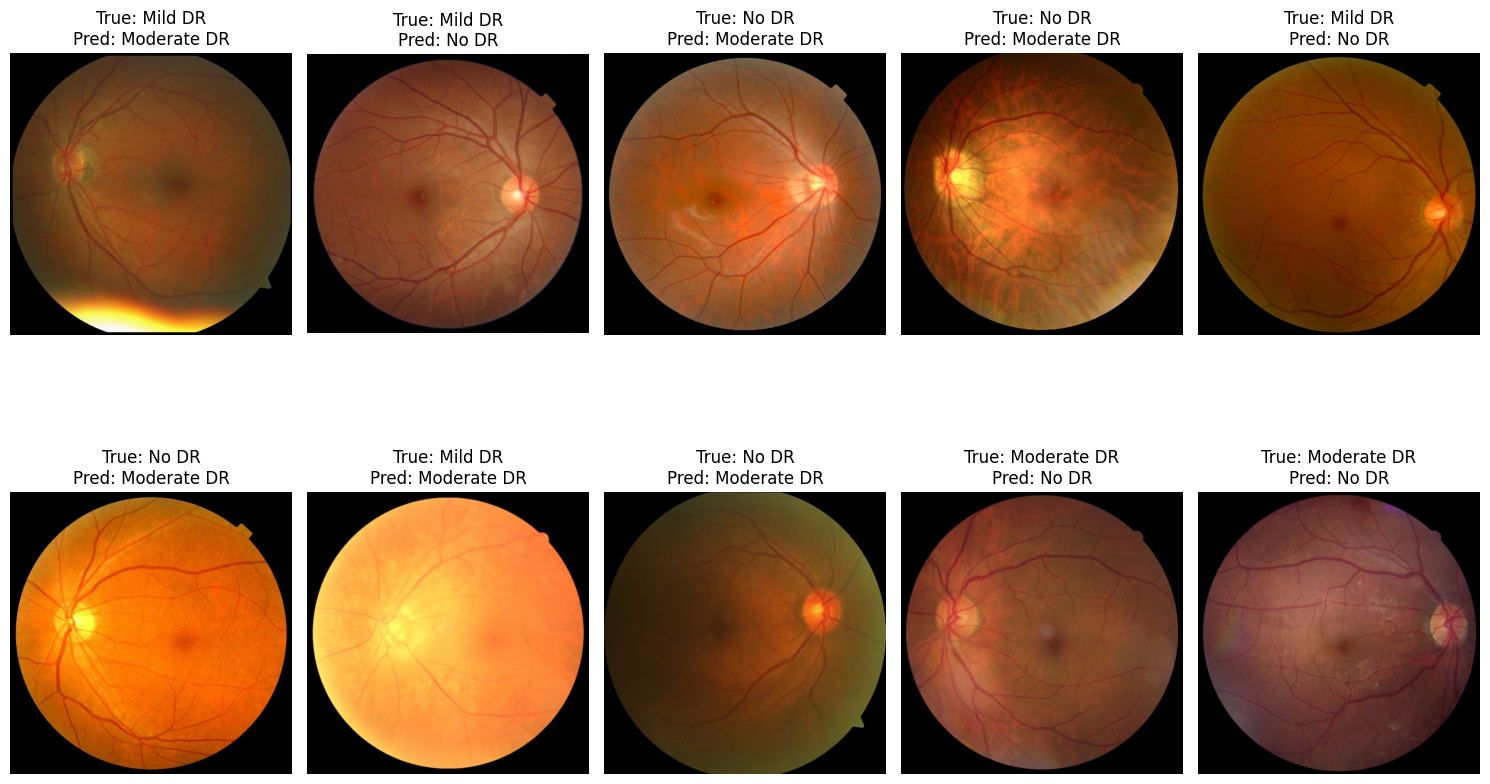

In [27]:
### Visual Error Analysis

import matplotlib.pyplot as plt
from PIL import Image

sample_errors = misclassified.sample(
    n=min(10, len(misclassified)),
    random_state=42
)

plt.figure(figsize=(15, 10))

for i, (_, row) in enumerate(sample_errors.iterrows()):

    image = Image.open(row["filepath"])

    plt.subplot(2, 5, i + 1)
    plt.imshow(image)

    true_label = class_names[int(row["true_class"])]
    pred_label = class_names[int(row["predicted_class"])]

    plt.title(
        f"True: {true_label}\nPred: {pred_label}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

EfficientNetB0 Results Summary:

EfficientNetB0 was evaluated on the unseen test set using accuracy, precision, recall, F1-score, ROC-AUC, and a confusion matrix.

The model achieved a test accuracy of 43.69%.
The ROC-AUC values were
 0.6762 for No DR,
 0.4797 for Mild DR,
 0.4753 for Moderate DR,
 0.6304 for Severe DR,
 0.7114 for Proliferative DR.

 The error analysis identified 1,058 misclassified images out of 1,879 test images, corresponding to a misclassification rate of approximately 56.31%.
 Visual inspection of selected misclassified samples shows that the model frequently confuses neighbouring diabetic retinopathy severity levels, particularly No DR, Mild DR, and Moderate DR. These errors may reflect the visual similarity between disease grades and the class imbalance present in the dataset.
